<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day07/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Heart.csv to Heart (1).csv
FIRST FIVE RECORDS
   Unnamed: 0  Age  Sex     ChestPain  RestBP  Chol  Fbs  RestECG  MaxHR  \
0           1   63    1       typical     145   233    1        2    150   
1           2   67    1  asymptomatic     160   286    0        2    108   
2           3   67    1  asymptomatic     120   229    0        2    129   
3           4   37    1    nonanginal     130   250    0        0    187   
4           5   41    0    nontypical     130   204    0        2    172   

   ExAng  Oldpeak  Slope   Ca        Thal  AHD  
0      0      2.3      3  0.0       fixed   No  
1      1      1.5      2  3.0      normal  Yes  
2      1      2.6      2  2.0  reversable  Yes  
3      0      3.5      3  0.0      normal   No  
4      0      1.4      1  0.0      normal   No  

Dataset Shape: (303, 15)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---

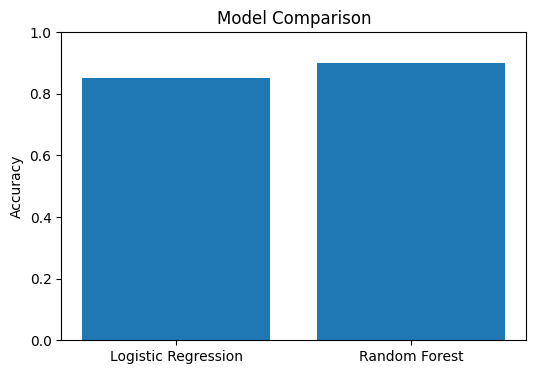


Confusion Matrix
[[27  2]
 [ 4 28]]


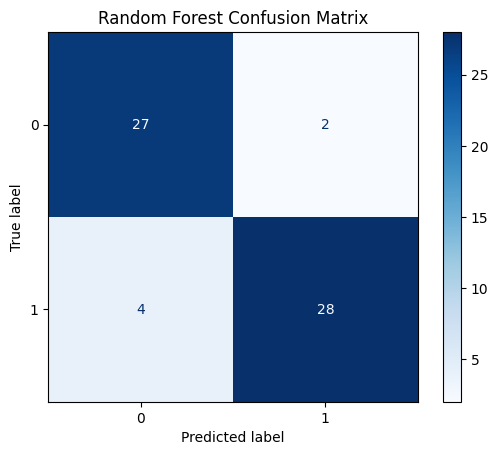


Classification Report
              precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61


Feature Importance
      Feature  Importance
2   ChestPain    0.128139
7       MaxHR    0.118952
11         Ca    0.115083
9     Oldpeak    0.107820
0         Age    0.100488
12       Thal    0.086507
4        Chol    0.085303
3      RestBP    0.068379
10      Slope    0.061980
8       ExAng    0.056216
1         Sex    0.034971
6     RestECG    0.023293
5         Fbs    0.012869


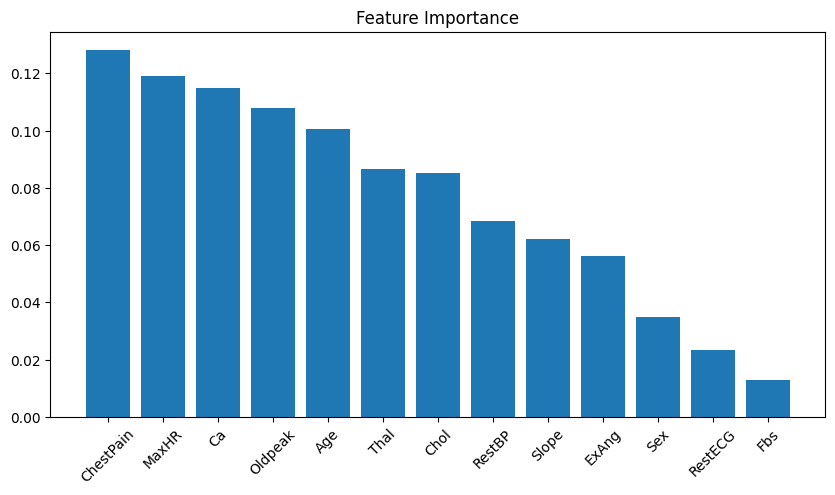


Heart_Disease_Output.csv Saved Successfully


PROJECT SUMMARY
Dataset : Heart (1).csv
Total Records : 303
Logistic Regression : 85.25 %
Random Forest : 90.16 %
Best Model : Random Forest


In [2]:
# ==========================================================
# DAY07 - HEART DISEASE PREDICTION
# Classification
# Author : Rajeswari P
# ==========================================================

# ==========================
# Step 1 : Upload Dataset
# ==========================

from google.colab import files

uploaded = files.upload()

import pandas as pd

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# ==========================
# Step 2 : Import Libraries
# ==========================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# ==========================
# Step 3 : Data Exploration
# ==========================

print("="*60)
print("FIRST FIVE RECORDS")
print("="*60)

print(df.head())

print("\nDataset Shape:",df.shape)

print("\nDataset Information")

print(df.info())

print("\nMissing Values")

print(df.isnull().sum())

print("\nStatistical Summary")

print(df.describe())

# ==========================
# Step 4 : Handle Missing Values
# ==========================

df["Ca"] = df["Ca"].fillna(df["Ca"].median())

df["Thal"] = df["Thal"].fillna(df["Thal"].mode()[0])

# ==========================
# Step 5 : Drop Unnecessary Column
# ==========================

df.drop("Unnamed: 0",axis=1,inplace=True)

# ==========================
# Step 6 : Label Encoding
# ==========================

encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype=="object":

        df[col]=encoder.fit_transform(df[col])

# ==========================
# Step 7 : Features & Target
# ==========================

X=df.drop("AHD",axis=1)

y=df["AHD"]

# ==========================
# Step 8 : Feature Scaling
# ==========================

scaler=StandardScaler()

X=scaler.fit_transform(X)

# ==========================
# Step 9 : Train Test Split
# ==========================

X_train,X_test,y_train,y_test=train_test_split(

X,
y,
test_size=0.20,
random_state=42

)

# ==========================
# Step 10 : Logistic Regression
# ==========================

lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

lr_pred=lr.predict(X_test)

lr_acc=accuracy_score(y_test,lr_pred)

print("\nLogistic Regression Accuracy :",lr_acc)

# ==========================
# Step 11 : Random Forest
# ==========================

rf=RandomForestClassifier(

n_estimators=100,

random_state=42

)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

rf_acc=accuracy_score(y_test,rf_pred)

print("Random Forest Accuracy :",rf_acc)

# ==========================
# Step 12 : Accuracy Comparison
# ==========================

plt.figure(figsize=(6,4))

models=["Logistic Regression","Random Forest"]

accuracy=[lr_acc,rf_acc]

plt.bar(models,accuracy)

plt.ylim(0,1)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

# ==========================
# Step 13 : Confusion Matrix
# ==========================

cm=confusion_matrix(y_test,rf_pred)

print("\nConfusion Matrix")

print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.show()

# ==========================
# Step 14 : Classification Report
# ==========================

print("\nClassification Report")

print(classification_report(y_test,rf_pred))

# ==========================
# Step 15 : Feature Importance
# ==========================

importance=pd.DataFrame({

"Feature":df.drop("AHD",axis=1).columns,

"Importance":rf.feature_importances_

})

importance=importance.sort_values(

by="Importance",

ascending=False

)

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(10,5))

plt.bar(

importance["Feature"],

importance["Importance"]

)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

# ==========================
# Step 16 : Save Predictions
# ==========================

results=pd.DataFrame({

"Actual":y_test.values,

"Predicted":rf_pred

})

results.to_csv(

"Heart_Disease_Output.csv",

index=False

)

print("\nHeart_Disease_Output.csv Saved Successfully")

# ==========================
# Step 17 : Project Summary
# ==========================

print("\n")

print("="*60)

print("PROJECT SUMMARY")

print("="*60)

print("Dataset :",filename)

print("Total Records :",len(df))

print("Logistic Regression :",round(lr_acc*100,2),"%")

print("Random Forest :",round(rf_acc*100,2),"%")

if lr_acc>rf_acc:

    print("Best Model : Logistic Regression")

else:

    print("Best Model : Random Forest")

print("="*60)